In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
df=sns.load_dataset("iris")

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


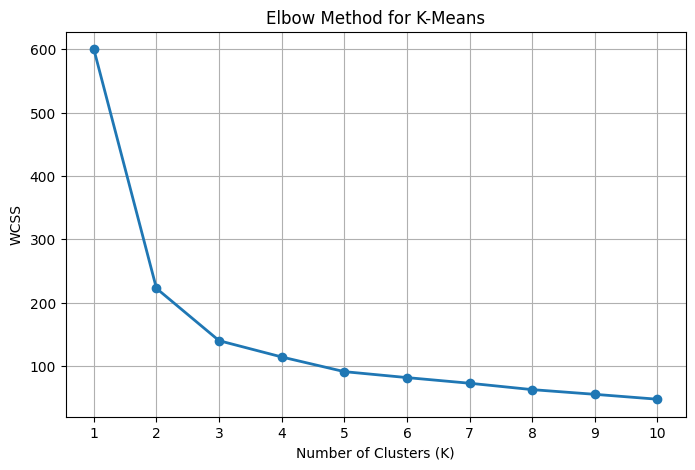

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Display data
print(df.head())

# Select features
X = df.copy()

# Standardize features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

# ---------------------------------------
# Elbow Method
# ---------------------------------------

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()



In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters



In [ ]:
score=silhouette_score(X_scaled,clusters)
print("\nSilhouette Score:",score)



Silhouette Score: 0.45994823920518635


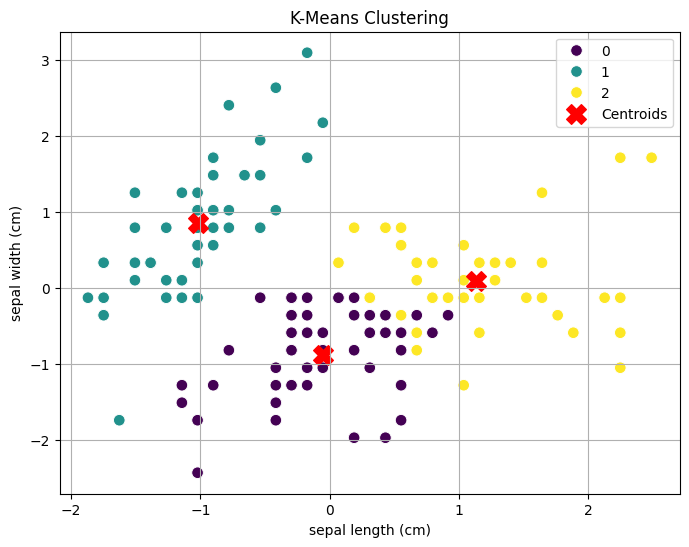

In [ ]:
feature_names = iris.feature_names

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters,
    palette="viridis",
    s=70
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    c="red",
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
for i, w in enumerate(wcss):
    print(f"For k={i+1}, WCSS = {w:.2f}")

For k=1, WCSS = 600.00
For k=2, WCSS = 222.36
For k=3, WCSS = 139.82
For k=4, WCSS = 114.09
For k=5, WCSS = 90.93
For k=6, WCSS = 81.54
For k=7, WCSS = 72.63
For k=8, WCSS = 62.54
For k=9, WCSS = 55.12
For k=10, WCSS = 47.39


In [ ]:
iris = load_iris()
x = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target,name='species')
species_names = iris.target_names

In [ ]:
print("First 5 rows:\n" , x.head())

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
print("First 5 rows:\n" , x.head())
print("\nMissing values:\n" ,x.isnull().sum())
print("\nData types:\n" ,x.dtypes)
print("\nDescriptive stats:\n", x.describe())

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Descriptive stats:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866    